In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

In [5]:
## Document Load
loader = PyPDFLoader("../data/medical_report.pdf")
docs = loader.load()

## split - Chunks
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
docs = splitter.split_documents(docs)

## embeddings and Vector DB
embed = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")
vector_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embed
)

In [6]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [7]:
class RagState(BaseModel):
    question: str = Field(description="User Question")
    documents : list = []
    context : str = Field(description="Context Data for user question", default="")
    answer : str = Field(description="Final Answer...", default="")

In [8]:
# question -> retrieve -> context -> generate -> end

def retrieve_node(state:RagState) -> RagState:
    docs = vector_store.similarity_search(query=state.question)
    state.documents = docs
    return state


def create_context_node(state:RagState) -> RagState:
    context = ""
    for doc in state.documents:
        context += doc.page_content + "\n\n"
    state.context = context
    return state


def generate_node(state:RagState) -> RagState:
    prompt = f"""
        You are a assistant and provide the answer for user question based on the provided context.
        If you don't find the relevant answer, then just say 'I dont know.'.
        Context is: {state.context},
        Questions is: {state.question}
    """
    res = llm.invoke(prompt)
    state.answer = res.content
    return state

In [9]:
graph = StateGraph(RagState)

graph.add_node("retrieve_node", retrieve_node)
graph.add_node("create_context_node", create_context_node)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, 'retrieve_node')
graph.add_edge("retrieve_node", "create_context_node")
graph.add_edge("create_context_node", "generate_node")
graph.add_edge("generate_node", END)

graph = graph.compile()

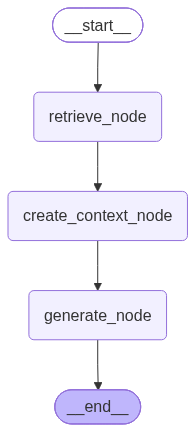

In [10]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [11]:
res = graph.invoke({"question":"What is the value of RBC and is it in a range ?"})

In [12]:
print(res["answer"])

**RBC Count:** 4.47 million cells per mm³  
**Reference range:** 3.80 – 4.80 million cells per mm³  

So the RBC value is within the normal range.
